# Creation of the first NN
Basic case of shear cube with one varying parameter

In [7]:
######### LIBRARIES ############
# RICORDA DI ELIMINARE TUTTE LIBRERIE CHE NON UTILIZZI
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import pandas
import pickle
import os

seed = 7
np.random.seed(seed)


## Introduction of the data

In [8]:
HF_data = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/HF_num_data.txt").astype(int) #list of number of HF data
Nlf_models = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/N_bases.txt").astype(int)[0:2]
HF_data_str = [str(num) for num in HF_data]

Young_train_LF = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_train_LF_young.txt")
Nlf=np.size(Young_train_LF)
Young_min = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_min_young.txt")[0]
Young_max = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_max_young.txt")[0]
U_train_LF_full = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/Ulf_train_young.txt")[:,0:2]

permutation = np.random.permutation(len(Young_train_LF))
Young_train_LF=Young_train_LF[permutation][0:10]

U_train_LF_full=U_train_LF_full[permutation][0:10]

In [9]:
Young_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/mu_test_young.txt")
#U_test_HF = np.loadtxt("../DATA_shear_cube/Young/Data_Test_bases_young/Uhf_test_young.txt")
U_test_LF_full = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/Ulf_test_young.txt")[:,0:2]
N_test_basis = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/N_bases.txt")

# Nlf_models = np.loadtxt("./Data/N_vect.txt").astype(int)   #list of number of bases

In [10]:
# NORMALIZATION 
# due righe ottimizzabili
Young_test=Young_test[:,0]
Young_train_LF=Young_train_LF[:,0]

# ADD NOISE

#noise_stddev = np.mean(U_train_LF_full)*0.1
#noise = np.random.normal(0, noise_stddev, np.shape(U_train_LF_full))
#U_train_LF_full=U_train_LF_full+noise

#noise_stddev = np.mean(Young_train_LF)*0.1
#noise = np.random.normal(0, noise_stddev, len(Young_train_LF))
#Young_train_LF=Young_train_LF+noise

Nlf = np.size(Young_train_LF)  #number of low-fidelity data to TRAIN the NN

Young_norm = (Young_test - Young_min) / (Young_max - Young_min)
Young_LF_norm = (Young_train_LF - Young_min) / (Young_max - Young_min)

U_train_LF_full= np.exp(U_train_LF_full*100)*1e-6
U_test_LF_full = np.exp(U_test_LF_full*100)*1e-6

U_t_max_train=np.max(U_train_LF_full)
U_t_min_train=np.min(U_train_LF_full)

U_t_max_test=np.max(U_test_LF_full)
U_t_min_test=np.min(U_test_LF_full)

U_lf_train=(U_train_LF_full-U_t_min_train)/(U_t_max_test-U_t_min_test)
U_lf_test=(U_test_LF_full-U_t_min_test)/(U_t_max_test-U_t_min_test)




# TRANSFORMATION 
# in order to reduce the linear relationship between the Young modulus and the displacement
#U_train_LF_full = np.exp(U_train_LF_full*100)*1e-6
#U_test_LF_full = np.exp(U_test_LF_full*100)*1e-6


In [11]:

NepoLF = 3000                          # number of epochs for first NN: NN_LF
NepoHF = 3000                          # number of epochs for second NN: NN_HF

U_LF_list=[]
U_HF_list=[]

# HF_data = np.loadtxt("./Data/HF_num_data.txt").astype(int) #list of number of HF data -> numero di dati HF. Scopo è capire quanti dati precisi sono necessari per delle buone performance
#HF_data = np.array([Young_train_HF.size-1, Young_train_HF.size])      # !!!! ATTENZIONE: da modificare per poter erificare varie numerosità !!!!!!!
HF_data_str = [str(num) for num in HF_data]
r2_HF_df = pandas.DataFrame(index=HF_data_str)             #dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame()                              #dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(index=HF_data_str)            #dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame()                             #dataframe which stores LF MSE

for m in range(len(Nlf_models)):
# loop over the basis    
        print(f"********************  #basis functions = {Nlf_models[m]}  ********************")
        
        test_mse_HF_list  = []
        test_mse_LF_list  = []

        r2_HF_list  = []
        r2_LF_list  = []
        
        #########################     TRAIN SET      ##########################
        U_train_LF=U_train_LF_full[:,m]
        
        #########################     TRAIN SET      ##########################
        U_test_LF=U_test_LF_full[:,m]
        
        ##########################     NORMALIZATION  ##########################
        #Output
        #lfmean = np.mean(U_test_LF)        # PERCHE LA MEDIA SOLO DI U_test_LF ???????????????????

        #U_train_LF = U_train_LF - lfmean
        #U_test_LF = U_test_LF - lfmean
        
        #U_train_LF= np.exp(U_train_LF*100)*1e-6
        #U_test_LF = np.exp(U_test_LF*100)*1e-6
        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}  # <------------------ 

        modelLF = getModel(bestLF_params,'LF')     # ann_functions
        histLF = modelLF.fit(Young_LF_norm, U_train_LF ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
#        histLF = modelLF.fit(Young_LF_norm[:,0], U_train_LF ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
# attenzione -> QUANDO LO FARAI IN PIU DIMENSIONI DI INPUT QUESTA PARTE E' DA SCRIVERE TENENDO CONTO DELLE DIMNSIONI EFFETTIVE DELLA MATRICE DI INPUT, DATO CHE NON POTRAI TAGLIARE ALL'INIZIO
        print('LF NN done')

        ULF = modelLF.predict(Young_test)
        
        U_LF_list.append(ULF)
        print('\nLF Model:')

        test_mse = np.mean(np.square(U_test_LF - ULF[:,0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_test_LF - ULF[:,0])) / np.sum(np.square(U_test_LF - np.mean(U_test_LF)))
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        
        for n_HF in HF_data:
        #loop over the possible numbers of high-fidelity data

                print(f"\n-------  #HF data = {n_HF}  -------")
                start = perf_counter()

                n_HF_txt = str(n_HF) + '.txt'

                #########################     TRAIN SET      #########################
                Young_train_HF = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_train_HF_young_" + n_HF_txt)[:,0]   # serve quando si provano diverso numero di dati                  
                Nhf = np.size(Young_train_HF)  # number of high-fidelity data to TRAIN the NN
# APPUNTO: cambiare nome a U_hf, per adattarlo a scrittura Uhf?
                U_hf_train = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/Uhf_train_young_" + n_HF_txt)      # ""
                
                permutation = np.random.permutation(len(Young_train_HF))
                Young_train_HF=Young_train_HF[permutation][0:5]
                U_hf_train=U_hf_train[permutation][0:5] 
                
                #########################     TEST SET      ##########################
                U_hf_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/Uhf_test_young.txt")

                ##########################     NORMALIZATION  ##########################
                # TRANSFORMATION
#                U_hf_train = np.exp(U_hf_train*100)*1e-6
#                U_hf_test = np.exp(U_hf_test*100)*1e-6
                
                #Input
                Young_train_HF_norm = (Young_train_HF - Young_min) / (Young_max - Young_min)

                #Output
                #hfmean = np.mean(U_hf_test)

                #U_hf_train = U_hf_train - hfmean
                #U_hf_test = U_hf_test - hfmean

                U_hf_train = np.exp(U_hf_train*100)*1e-6
                U_hf_test = np.exp(U_hf_test*100)*1e-6
                
                U_t_min_test=np.min(U_hf_test,axis=0)
                U_t_max_test=np.max(U_hf_test,axis=0)
                
                U_t_min_train=np.min(U_hf_train,axis=0)
                U_t_max_train=np.max(U_hf_train,axis=0)
                
                U_hf_train=(U_hf_train-U_t_min_train)/(U_t_max_train-U_t_min_train)
                U_hf_test=(U_hf_test-U_t_min_test)/(U_t_max_test-U_t_min_test)

                ##########################    SECOND NN: NN_HF    ##########################
                Young_test_help = modelLF.predict(Young_norm)[:,0]
                Young_test_in = np.vstack((Young_norm,Young_test_help)).transpose() # <- TEST INPUT for the second NN: NN_HF

                Young_train_help = modelLF.predict(Young_train_HF_norm)[:,0] #f_LF(mu_hf_train)
                Young_final = np.vstack((Young_train_HF_norm ,Young_train_help)).transpose() # <- TRAINING INPUT for the second NN: NN_HF

                name = '2step'
                K.clear_session()
                #best paramters obtained by HPO:
                # Young
                #best_param = {'kernel_init': 'uniform', 'l2weight': 0.00012051711558537875, 'lr': 0.0017624104175516413, 'nodes': 18.0, 'opt': 'Adamax'}
                #best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010669470437554761, 'lr': 0.015298517193401867, 'nodes': 12.0, 'opt': 'Adamax'}
                #best_params={'kernel_init': 'uniform', 'l2weight': 0.00021280958667909701, 'lr': 0.01280013966561744, 'nodes': 6.0, 'opt': 'Adam'}
                # Poisson
                best_params={'kernel_init': 'uniform', 'l2weight': 0.00014792980965688785, 'lr': 0.00033536498844198136, 'nodes': 56.0, 'opt': 'Adam'}
                #100%|██████████| 15/15 [28:24<00:00, 113.64s/trial, best loss: 4.971638652351829e-06] {'kernel_init': 'uniform', 'l2weight': 0.000807831416040378, 'lr': 0.0052322673829551325, 'nodes': 48.0, 'opt': 'Adam'
                finalModel = getModel(best_params,name) #final model chosen according to the best paramters
                hist = finalModel.fit(Young_final, U_hf_train, validation_data=(Young_test_in, U_hf_test),epochs=NepoHF,batch_size=Nhf,verbose=0, validation_freq = 20)

                UHF = finalModel.predict(Young_test_in)
                U_HF_list.append(UHF)

                stop = perf_counter()
                elapsed = stop - start
                print('Elapsed time: ', elapsed)
                print('\nHF Model:')

                test_mse = np.mean(np.square(U_hf_test - UHF[:,0]))
                test_mse_HF_list.append(test_mse)
                print(f"Test MSE: {test_mse}")

                r2_HF = 1 - np.sum(np.square(U_hf_test - UHF[:,0])) / np.sum(np.square(U_hf_test - np.mean(U_hf_test)))
                r2_HF_list.append(r2_HF)
                print(f"R^2: {r2_HF}")        
        
        
        r2_LF_df[str(Nlf_models[m])] = r2_LF_list
        r2_HF_df[str(Nlf_models[m])] = r2_HF_list

        mse_LF_df[str(Nlf_models[m])] = test_mse_LF_list
        mse_HF_df[str(Nlf_models[m])] = test_mse_HF_list      

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))    

********************  #basis functions = 1  ********************
LF NN done
4/4 [==============================] - 0s 0s/step

LF Model:
Test MSE: 4.601584307054797
R^2: -57.98773983498462

-------  #HF data = 5  -------
4/4 [==============================] - 0s 3ms/step
Elapsed time:  24.52128709992394

HF Model:
Test MSE: 0.0006688273711824913
R^2: 0.9912674623692503

-------  #HF data = 7  -------
4/4 [==============================] - 0s 0s/step
Elapsed time:  23.868623699992895

HF Model:
Test MSE: 0.0019631435023821013
R^2: 0.9743682372346634

-------  #HF data = 9  -------
4/4 [==============================] - 0s 7ms/step
Elapsed time:  23.09044850000646

HF Model:
Test MSE: 0.0030539305405151746
R^2: 0.9601263875914735

-------  #HF data = 11  -------
4/4 [==============================] - 0s 2ms/step
Elapsed time:  22.381654399912804

HF Model:
Test MSE: 0.0034731795010893595
R^2: 0.954652467888705

-------  #HF data = 13  -------
4/4 [==============================] - 0s 7ms

4/4 [==============================] - 0s 3ms/step


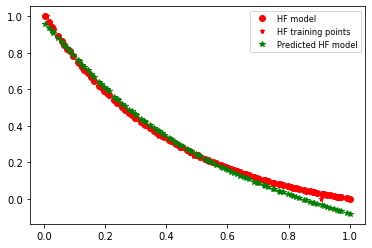

In [12]:
plt.figure()
plt.plot(Young_test_in[:,0], U_hf_test,'ro', linewidth = 1.5, label = 'HF model')
plt.plot(Young_final[:,0], U_hf_train,'r*', markersize = 5, label = 'HF training points')
plt.plot(Young_test_in[:,0], finalModel.predict(Young_test_in), 'g*',linewidth = 3, label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

In [14]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs('Output_MF_rel_no_noise')

r2_HF_df.to_csv('./Output_MF_rel_no_noise/r2_HF_lhs_transformation.txt', header=True, index=False, sep='\t', mode='a')
mse_HF_df.to_csv('./Output_MF_rel_no_noise/mse_HF_lhs_transformation.txt', header = True, index = False, sep = '\t', mode = 'a')
r2_LF_df.to_csv('./Output_MF_rel_no_noise/r2_LF_lhs_transformation.txt', header=True, index=False, sep='\t', mode='a')
mse_LF_df.to_csv('./Output_MF_rel_no_noise/mse_LF_lhs_transformation.txt', header = True, index = False, sep = '\t', mode = 'a')

with open('./Output_MF_rel_no_noise/U_HF_list_transformation.data', 'wb') as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open('./Output_MF_rel_no_noise/U_LF_list_transformation.data', 'wb') as filehandle:
    pickle.dump(U_LF_list, filehandle)